# 1. Data Preparing

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display numbers
pd.options.display.float_format = '{:20.2f}'.format
from matplotlib.ticker import FuncFormatter

# Show all columns
pd.set_option('display.max_columns', None)

c:\Users\Student\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Student\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## EDA

#### **Loading data**

In [2]:
# Load data
df = pd.read_excel(
    '../datasets/online_retail_II.xlsx',
    sheet_name="Year 2010-2011"
    )

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.00,541910,541910.00,406830.00
mean,9.55,2011-07-04 13:35:22.342307,4.61,15287.68
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [5]:
df.describe(include='O')

C:\Users\Student\AppData\Local\Temp\ipykernel_18248\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,Invoice,StockCode,Description,Country
count,541910,541910,540456,541910
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


The main concerns that stands out are the negative quantity values and      
the negative minimun value on price. Further analysis will be conducted to evaluate each column.

#### **Missing values**

In [6]:
# Renaming columns
df.rename(columns={
    "Invoice": "InvoiceNo",
    "Customer ID": "CustomerID",
    "Price":"UnitPrice"
    }, inplace=True)

In [7]:
# Checking missing values
missing_pct = df.isna().mean().mul(100).round(2)

print(missing_pct[missing_pct > 0])

Description                   0.27
CustomerID                   24.93
dtype: float64


In [8]:
# Saving dataset before dropping values
before = df.copy()

# Dropping values with no customers
df = df.dropna(subset=['CustomerID'])

# Calculating percentage of dataset after dropped missing values
percentage_of_total = round(len(df) / len(before) * 100, 2)
print(f'Percentage of total dataset left after dropping values: {percentage_of_total}')

# Checking null values by column
df.isnull().sum()

Percentage of total dataset left after dropping values: 75.07


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### **Categorical Features**

##### InvoiceNo

In [9]:
# data type
print(f"Data type: {df['InvoiceNo'].dtype}")

# unique values
print(f"Unique invoiceno count: {df['InvoiceNo'].nunique()}")

# Converting InvoiceNo values
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Sample of values
print(df['InvoiceNo'].sort_values(ascending=False))

Data type: object
Unique invoiceno count: 22190
541716    C581569
541717    C581569
541715    C581568
541541    C581499
540448    C581490
           ...   
2          536365
3          536365
4          536365
5          536365
6          536365
Name: InvoiceNo, Length: 406830, dtype: str


Let's investigate the letters in InvoiceNo

In [10]:
# Setting variable for just digits / checking pattern
just_number = r'^\d+$'

# Creating a mask for values different from a number
mask_diff_number = ~df['InvoiceNo'].str.strip().str.match(just_number)

# Checking invalid patterns 
invalid_entries = df[mask_diff_number]['InvoiceNo'].unique()
df[mask_diff_number].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.00,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.00,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.00,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.00,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.00,United Kingdom


Negative quantities = cancelled orders \
They will be dropped

In [11]:
# Dropping cancellations
df = df[~mask_diff_number]

# Checking total dataset left
percentage_of_total = round(len(df) / len(before) * 100, 2)
print(f'Percentage of total dataset left after dropping values: {percentage_of_total}')

Percentage of total dataset left after dropping values: 73.43


In [12]:
# Checking if all InvoiceNo are just numbers
df[~df['InvoiceNo'].str.strip().str.match(just_number)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


##### StockCode

In [13]:
# data type
print(f"Data type: {df['StockCode'].dtype}")

# unique values
print(f"Unique stockcode count: {df['StockCode'].nunique()}")

# Sample of values
print(df['StockCode'].value_counts().head(10))

Data type: object
Unique stockcode count: 3665
StockCode
85123A    2035
22423     1724
85099B    1618
84879     1408
47566     1397
20725     1317
22720     1159
20727     1105
POST      1100
23203     1098
Name: count, dtype: int64


In [14]:
# Converting StockCode data type
df['StockCode'] = df['StockCode'].astype(str)

In [15]:
# Setting variable for 5 numbers and one letter
numbers_letters = r'^\d{5}[A-Za-z]?$'

# Creating mask for the invalid stock
mask_invalid_stock = ~df['StockCode'].str.strip().str.match(numbers_letters)

# Checking each invalid stock unique value
df[mask_invalid_stock]['StockCode'].value_counts()

StockCode
POST            1100
15056BL          291
M                290
C2               133
DOT               16
BANK CHARGES      12
PADS               4
Name: count, dtype: int64

Any values different from 5 numbers and 1 letter were selected for validation

In [16]:
df[df['StockCode'] == 'POST'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.00,France
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791.00,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.00,12662.00,Germany
5095,536840,POST,POSTAGE,1,2010-12-02 18:27:00,18.00,12738.00,Germany
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00,18.00,12686.00,France


In [17]:
df[df['StockCode'] == 'M'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.00,United Kingdom
2250,536569,M,Manual,1,2010-12-01 15:35:00,18.95,16274.00,United Kingdom
6798,536981,M,Manual,2,2010-12-03 14:26:00,0.85,14723.00,United Kingdom
7976,537077,M,Manual,12,2010-12-05 11:59:00,0.42,17062.00,United Kingdom
8530,537137,M,Manual,36,2010-12-05 12:43:00,0.85,16327.00,United Kingdom


In [18]:
df[df['StockCode'] == 'C2'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911.00,EIRE
12119,537368,C2,CARRIAGE,1,2010-12-06 12:40:00,50.00,14911.00,EIRE
12452,537378,C2,CARRIAGE,1,2010-12-06 13:06:00,50.00,14911.00,EIRE
19975,537963,C2,CARRIAGE,1,2010-12-09 11:30:00,50.00,13369.00,United Kingdom
20016,538002,C2,CARRIAGE,1,2010-12-09 11:48:00,50.00,14932.00,Channel Islands


In [19]:
df[df['StockCode'] == 'DOT'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
317507,564764,DOT,DOTCOM POSTAGE,1,2011-08-30 10:49:00,11.17,14096.00,United Kingdom
324002,565383,DOT,DOTCOM POSTAGE,1,2011-09-02 15:45:00,16.46,14096.00,United Kingdom
333756,566217,DOT,DOTCOM POSTAGE,1,2011-09-09 15:17:00,13.16,14096.00,United Kingdom
338830,566566,DOT,DOTCOM POSTAGE,1,2011-09-13 12:32:00,85.58,14096.00,United Kingdom
350600,567656,DOT,DOTCOM POSTAGE,1,2011-09-21 14:40:00,878.55,14096.00,United Kingdom


In [20]:
df[df['StockCode'] == 'PADS'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.00,13952.00,United Kingdom
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.00,15618.00,United Kingdom
358670,568158,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 12:22:00,0.00,16133.00,United Kingdom
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.00,16198.00,United Kingdom


In [21]:
df[df['StockCode'] == '15056BL'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
132,536381,15056BL,EDWARDIAN PARASOL BLACK,2,2010-12-01 09:41:00,5.95,15311.00,United Kingdom
283,536396,15056BL,EDWARDIAN PARASOL BLACK,6,2010-12-01 10:51:00,4.95,17850.00,United Kingdom
1219,536531,15056BL,EDWARDIAN PARASOL BLACK,12,2010-12-01 13:23:00,5.95,15485.00,United Kingdom
4164,536750,15056BL,EDWARDIAN PARASOL BLACK,6,2010-12-02 14:04:00,4.95,17850.00,United Kingdom
4185,536752,15056BL,EDWARDIAN PARASOL BLACK,6,2010-12-02 14:06:00,4.95,17850.00,United Kingdom


PADS and 15056BL are legit products.     
As PADS has no UnitPrice, they don't have valuable information for our analysis.     
We will keep just 15056BL.

In [22]:
# Setting variable for 5 numbers and one or more letters after number
numbers_letters2 = r'^\d{5}[A-Za-z]*$'

# Creating mask for the invalid stock
mask_invalid_stock2 = ~df['StockCode'].str.strip().str.match(numbers_letters2)

# Checking each invalid stock unique value
df[mask_invalid_stock2]['StockCode'].value_counts()


# Dropping invalid values from Stock Code
df = df[~mask_invalid_stock2]

# Checking total dataset left
percentage_of_total = round((len(df) / len(before)) * 100)
print(f'Percentage of total dataset left after dropping values: {percentage_of_total}')

Percentage of total dataset left after dropping values: 73


##### Description

In [23]:
# data type
print(f"Data type: {df['Description'].dtype}")

# unique values
print(f"Unique description count: {df['Description'].nunique()}")

# Sample of values
print(df['Description'].value_counts().head(10))

Data type: object
Unique description count: 3871
Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1724
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1397
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
PACK OF 72 RETROSPOT CAKE CASES       1068
PAPER CHAIN KIT 50'S CHRISTMAS        1019
Name: count, dtype: int64


In [24]:
# Removing white spaces
df['Description'] = df['Description'].astype(str).str.strip()

# Creating mask for lowercase
mask_not_upper = ~df['Description'].str.isupper()

# Checking unique values and amount
df[mask_not_upper]['Description'].value_counts()

Description
BAG 125g SWIRLY MARBLES                247
3 TRADITIONAl BISCUIT CUTTERS  SET     205
BAG 250g SWIRLY MARBLES                198
POLYESTER FILLER PAD 40x40cm           182
POLYESTER FILLER PAD 45x45cm           134
BAG 500g SWIRLY MARBLES                112
Next Day Carriage                       79
FRENCH BLUE METAL DOOR SIGN No          73
POLYESTER FILLER PAD 45x30cm            37
POLYESTER FILLER PAD 30CMx30CM          26
ESSENTIAL BALM 3.5g TIN IN ENVELOPE     18
NUMBER TILE COTTAGE GARDEN No           11
FOLK ART GREETING CARD,pack/12          10
NUMBER TILE VINTAGE FONT No              9
THE KING GIFT BAG 25x24x12cm             7
POLYESTER FILLER PAD 65CMx65CM           5
FLOWERS HANDBAG blue and orange          3
High Resolution Image                    3
POLYESTER FILLER PAD 60x40cm             1
Name: count, dtype: int64

In [25]:
df[df['Description'] == 'Next Day Carriage'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
205748,554835,23444,Next Day Carriage,1,2011-05-26 16:11:00,15.00,15241.00,United Kingdom
209588,555251,23444,Next Day Carriage,1,2011-06-01 15:12:00,15.00,13062.00,United Kingdom
210691,555312,23444,Next Day Carriage,1,2011-06-02 10:39:00,15.00,16484.00,United Kingdom
211341,555367,23444,Next Day Carriage,1,2011-06-02 14:28:00,15.00,17900.00,United Kingdom
218011,555948,23444,Next Day Carriage,1,2011-06-08 10:49:00,30.00,13752.00,United Kingdom


In [26]:
# The value identified as not a product was 'Next Day Carriage' and will be dropped
df = df[df['Description'] != 'Next Day Carriage']

In [27]:
# Making all upper case for consistency
df['Description'] = df['Description'].str.upper()

# Removing any space
df['Description'] = df['Description'].str.strip()

# Remove double stripes
df['Description'] = df['Description'].str.split().str.join(' ')

# Removing spaces around + values
df['Description'] = df['Description'].str.replace(r'\s*\+\s*', '+', regex=True)


##### Country

In [28]:
# unique values
print(f"Unique Country count: {df['Country'].nunique()}")

Unique Country count: 37


In [29]:
# Checking Unspecified countries
df[df['Country'] == 'Unspecified']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
152712,549687,20685,DOORMAT RED RETROSPOT,2,2011-04-11 13:29:00,7.95,12363.00,Unspecified
152713,549687,22691,DOORMAT WELCOME SUNRISE,2,2011-04-11 13:29:00,7.95,12363.00,Unspecified
152714,549687,48116,DOORMAT MULTICOLOUR STRIPE,2,2011-04-11 13:29:00,7.95,12363.00,Unspecified
152715,549687,21213,PACK OF 72 SKULL CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.00,Unspecified
152716,549687,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.00,Unspecified
...,...,...,...,...,...,...,...,...
308810,564051,23007,SPACEBOY BABY GIFT SET,1,2011-08-22 13:32:00,16.95,14265.00,Unspecified
308811,564051,21833,CAMOUFLAGE LED TORCH,12,2011-08-22 13:32:00,1.69,14265.00,Unspecified
308812,564051,23081,GREEN METAL BOX ARMY SUPPLIES,2,2011-08-22 13:32:00,8.25,14265.00,Unspecified
308813,564051,23046,PAPER LANTERN 9 POINT DELUXE STAR,2,2011-08-22 13:32:00,6.65,14265.00,Unspecified


I investigated the countries and identified Unspecified values. As 'Country' is not essential for the analysis, I made the decision to not change them.

##### CustomerID

In [30]:
# data type
print(f"Data type: {df['CustomerID'].dtype}")

# unique values
print(f"Unique CustomerID count: {df['CustomerID'].nunique()}")

# negative values
print(f"Negative CustomerIDs: {(df['CustomerID'] < 0).sum()}")

# min/max range
print(f"Min: {df['CustomerID'].min()} | Max: {df['CustomerID'].max()}")

# Sample of values
print(df['CustomerID'].value_counts().head(10))

Data type: float64
Unique CustomerID count: 4335
Negative CustomerIDs: 0
Min: 12346.0 | Max: 18287.0
CustomerID
17841.00    7838
14911.00    5591
14096.00    5095
12748.00    4580
14606.00    2697
15311.00    2379
14646.00    2064
13089.00    1818
13263.00    1672
14298.00    1637
Name: count, dtype: int64


In [31]:
# Converting data type into integer
df['CustomerID'] = df['CustomerID'].astype(int)

##### Date

In [32]:
# Converting date type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.date

#### **Numeric Features**

##### UnitPrice

In [33]:
# Checking min results
df['UnitPrice'].describe()

count              396291.00
mean                    2.87
std                     4.26
min                     0.00
25%                     1.25
50%                     1.95
75%                     3.75
max                   649.50
Name: UnitPrice, dtype: float64

In [34]:
# Filter UnitPrice less than  or equal 0.1
df[df['UnitPrice'] <= 0.1].groupby('Description')['UnitPrice'].agg(['mean', 'min', 'max', 'count'])

,mean,min,max,count
Description,,,,
36 FOIL STAR CAKE CASES,0.00,0.00,0.00,1
ADVENT CALENDAR GINGHAM SACK,0.00,0.00,0.00,1
ASS DES PHONE SPONGE CRAFT STICKER,0.09,0.09,0.09,2
ASSTD DESIGN 3D PAPER STICKERS,0.00,0.00,0.00,1
BISCUIT TIN VINTAGE CHRISTMAS,0.00,0.00,0.00,1
BLUE STONES ON WIRE FOR CANDLE,0.08,0.08,0.08,17
CARTOON PENCIL SHARPENERS,0.06,0.06,0.06,43
CERAMIC BOWL WITH LOVE HEART DESIGN,0.00,0.00,0.00,1
CHILDREN'S APRON DOLLY GIRL,0.00,0.00,0.00,1


There are a small number of near-zero price records that do not represent normal product sales.    
All values less than or equal 0.1 will be excluded.

In [35]:
# Dropping values
df = df[df['UnitPrice'] > 0.1]

In [36]:
# Checking min results (0.12)
print('min value:', df['UnitPrice'].min())

min value: 0.12


##### Quantity

In [37]:
# Quantity distribution
df['Quantity'].describe()

count              395975.00
mean                   12.93
std                   179.53
min                     1.00
25%                     2.00
50%                     6.00
75%                    12.00
max                 80995.00
Name: Quantity, dtype: float64

Max indicates the presence of outliers.
 

### **Outliers**

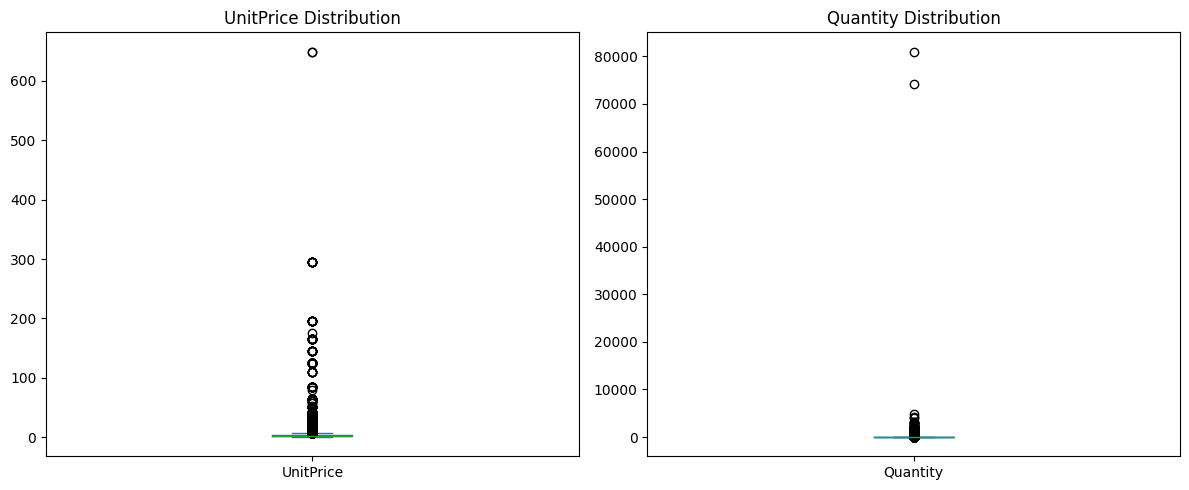

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['UnitPrice'].plot(kind='box', ax=axes[0], title='UnitPrice Distribution')
df['Quantity'].plot(kind='box', ax=axes[1], title='Quantity Distribution')

plt.tight_layout()
plt.show()

In [39]:
# Setting the threshold by visualization
df[(df['Quantity'] > 60000) | (df['UnitPrice'] > 250)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02,295.00,13145,United Kingdom
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16,295.00,16607,United Kingdom
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10,295.00,17406,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18,1.04,12346,United Kingdom
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04,295.00,14842,United Kingdom
118748,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14,295.00,13452,United Kingdom
134007,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25,295.00,13452,United Kingdom
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28,295.00,14973,United Kingdom
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26,295.00,13015,United Kingdom
222671,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10,649.50,15098,United Kingdom


Outliers are important for any e-commerce transactional dataset,      
but handle them can be hard as they can affect negatively any process.      
For that reason, just the extreme outliers will be removed from dataset.     
quantity  higher than 10000 = 2 values, and unitprice 649.50 = 2 values.      
Most of other outliers are in an acceptable range.    

In [40]:
# Dropping values
df = df[(df['Description'] != 'PICNIC BASKET WICKER 60 PIECES') & (df['Quantity'] < 10000)]

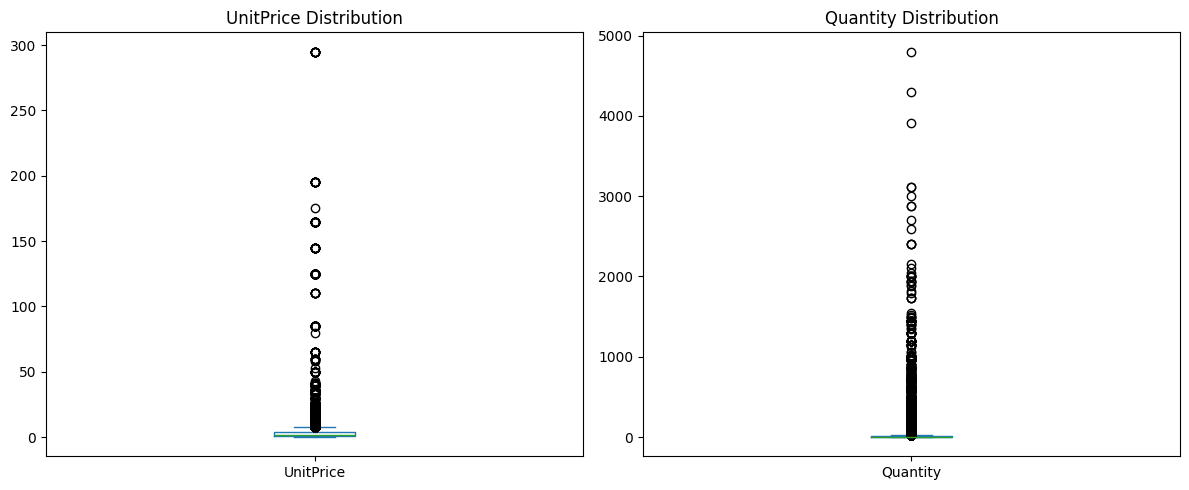

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['UnitPrice'].plot(kind='box', ax=axes[0], title='UnitPrice Distribution')
df['Quantity'].plot(kind='box', ax=axes[1], title='Quantity Distribution')

plt.tight_layout()
plt.show()

### **Duplicates**

##### Whole dataset

In [42]:
# Checking duplicated values
print('duplicated values:', df.duplicated().sum())

# Drop duplicates
print('After drop duplicates:', df.drop_duplicates(inplace=True))

# Checking total dataset left
percentage_of_total = len(df) / len(before) * 100
print(f'Percentage of total dataset left after dropping values: {percentage_of_total:.2f}%')

# Reset index
df = df.reset_index(drop=True)

duplicated values: 5185
After drop duplicates: None
Percentage of total dataset left after dropping values: 72.11%


##### By Transaction

In [43]:
# Checking duplicate
print(f'Duplicated values: {df.duplicated().sum()}')

# Checking duplicates in transactional level (Invoice + productcode + product description)
print(f'Duplicated values:{df.duplicated(subset=['InvoiceNo', 'StockCode', 'Description']).sum()}')
print(f'Duplicated values:{df.duplicated(subset=['InvoiceNo', 'Description']).sum()}')
print(f'Duplicated values:{df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()}')

# Checking duplicate values
duplicate_values = df[df.duplicated(subset=['InvoiceNo','Description'], keep=False)]
duplicate_values.sort_values(['InvoiceNo', 'Description']).head(20)

Duplicated values: 0
Duplicated values:4820
Duplicated values:5052
Duplicated values:4822


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
112,536381,71270,PHOTO CLIP LINE,1,2010-12-01,1.25,15311,United Kingdom
124,536381,71270,PHOTO CLIP LINE,3,2010-12-01,1.25,15311,United Kingdom
471,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01,6.35,17908,United Kingdom
486,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,1,2010-12-01,6.35,17908,United Kingdom
512,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,2,2010-12-01,6.35,17908,United Kingdom
479,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,1,2010-12-01,2.10,17908,United Kingdom
490,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,5,2010-12-01,2.10,17908,United Kingdom
548,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01,1.65,17920,United Kingdom
561,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01,1.65,17920,United Kingdom
556,536412,22243,5 HOOK HANGER RED MAGIC TOADSTOOL,6,2010-12-01,1.65,17920,United Kingdom


Multiple records were found for the same invoice and product.     
The same product appeared more than once within an invoice, with the quantity split across separate records.

In [44]:
# Cheking difference between Description and StockCode
print('Description unique values:', df['Description'].nunique())
print('StockCode unique values:', df['StockCode'].nunique())

Description unique values: 3846
StockCode unique values: 3655


In [45]:
# Check if one StockCode has multiple Descriptions
stock_multi_prod = df.groupby('StockCode')['Description'].nunique()
print("StockCodes with multiple Descriptions:")
print(stock_multi_prod[stock_multi_prod > 1].sort_values(ascending=False).count())
print('='*50)
print(stock_multi_prod[stock_multi_prod > 1].sort_values(ascending=False).head())
print('='*50)
print(df[df['StockCode'] == '23396'])


StockCodes with multiple Descriptions:
204
StockCode
23236     4
23196     4
22776     3
23244     3
17107D    3
Name: Description, dtype: int64
       InvoiceNo StockCode                        Description  Quantity  \
225753    565419     23396            BUTTERFLY CUSHION COVER         4   
226456    565444     23396  LA JARDIN BOTANIQUE CUSHION COVER         4   
226520    565445     23396  LA JARDIN BOTANIQUE CUSHION COVER         2   
228524    565734     23396  LA JARDIN BOTANIQUE CUSHION COVER         3   
229163    565795     23396  LA JARDIN BOTANIQUE CUSHION COVER         4   
...          ...       ...                                ...       ...   
376885    580282     23396  LE JARDIN BOTANIQUE CUSHION COVER         4   
379346    580520     23396  LE JARDIN BOTANIQUE CUSHION COVER         2   
384385    580893     23396  LE JARDIN BOTANIQUE CUSHION COVER         1   
387884    581233     23396  LE JARDIN BOTANIQUE CUSHION COVER         4   
389949    581456     23396  LE

In [46]:
# Check if one Description has multiple StockCodes
desc_multi_stock = df.groupby('Description')['StockCode'].nunique()
print("Descriptions with multiple StockCodes:")
print(desc_multi_stock[desc_multi_stock > 1].sort_values(ascending=False).count())
print('='*50)
print(desc_multi_stock[desc_multi_stock > 1].sort_values(ascending=False).head())
print('='*50)
print(df[df['Description'] == 'COLUMBIAN CANDLE ROUND'].head())

Descriptions with multiple StockCodes:
29
Description
COLUMBIAN CANDLE ROUND            3
METAL SIGN,CUPCAKE SINGLE HOOK    3
BATHROOM METAL SIGN               2
PINK FAIRY CAKE CUSHION COVER     2
STORAGE TIN VINTAGE LEAF          2
Name: StockCode, dtype: int64
     InvoiceNo StockCode             Description  Quantity InvoiceDate  \
2707    536741     72127  COLUMBIAN CANDLE ROUND         6  2010-12-02   
4633    536987     72130  COLUMBIAN CANDLE ROUND         1  2010-12-03   
4634    536987     72128  COLUMBIAN CANDLE ROUND         1  2010-12-03   
4635    536987     72127  COLUMBIAN CANDLE ROUND         1  2010-12-03   
9655    537484     72130  COLUMBIAN CANDLE ROUND        36  2010-12-07   

                UnitPrice  CustomerID         Country  
2707                 1.25       13117  United Kingdom  
4633                 0.65       17198  United Kingdom  
4634                 0.85       17198  United Kingdom  
4635                 1.25       17198  United Kingdom  
9655       

The relationship between StockCode and Description was also investigated.    
A total of 204 StockCodes were associated with multiple descriptions, while 26 descriptions were associated with multiple StockCodes.

In [47]:
# Dropping StockCode
df = df.drop(columns=['StockCode'])

Because the analysis treats product description as the product-level identifier, Description was retained as the main product field and StockCode was removed from the final dataset.     
The investigation of StockCode also helped identify non-product transaction records, which were evaluated and removed where appropriate.

In [48]:
# Checking any left duplicated on quantity and unitprice
print(df.duplicated(subset=['InvoiceNo', 'Description', 'InvoiceDate', 'CustomerID', 'Country']).sum())

# Checking by invoiceno and description
print(df.duplicated(subset=['InvoiceNo', 'Description']).sum())

5052
5052


In [49]:
# Grouping all values with quantity and unitprice to remove duplicated transactions
df = df.groupby(
    ['InvoiceNo', 'Description', 'InvoiceDate', 'CustomerID', 'Country'],
    as_index=False
).agg({'Quantity': 'sum', 'UnitPrice': 'mean'})

print(f"Duplicates: {df.duplicated(subset=['InvoiceNo', 'Description']).sum()}")

Duplicates: 0


## Feature Engineering

#### **Creating columns**

In [50]:
# TransactionID
df = df.reset_index(drop=True)
df['TransactionID'] = df['InvoiceNo'].astype(str) + '_' + (df.index + 1).astype(str).str.zfill(6)

# TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Verify
print(f"Total rows: {len(df)}")
print(f"Unique TransactionIDs: {df['TransactionID'].nunique()}")
df

Total rows: 385734
Unique TransactionIDs: 385734


,InvoiceNo,Description,InvoiceDate,CustomerID,Country,Quantity,UnitPrice,TransactionID,TotalPrice
0,536365,CREAM CUPID HEARTS COAT HANGER,2010-12-01,17850,United Kingdom,8,2.75,536365_000001,22.00
1,536365,GLASS STAR FROSTED T-LIGHT HOLDER,2010-12-01,17850,United Kingdom,6,4.25,536365_000002,25.50
2,536365,KNITTED UNION FLAG HOT WATER BOTTLE,2010-12-01,17850,United Kingdom,6,3.39,536365_000003,20.34
3,536365,RED WOOLLY HOTTIE WHITE HEART.,2010-12-01,17850,United Kingdom,6,3.39,536365_000004,20.34
4,536365,SET 7 BABUSHKA NESTING BOXES,2010-12-01,17850,United Kingdom,2,7.65,536365_000005,15.30
...,...,...,...,...,...,...,...,...,...
385729,581587,CIRCUS PARADE LUNCH BOX,2011-12-09,12680,France,12,1.95,581587_385730,23.40
385730,581587,PACK OF 20 SPACEBOY NAPKINS,2011-12-09,12680,France,12,0.85,581587_385731,10.20
385731,581587,PLASTERS IN TIN CIRCUS PARADE,2011-12-09,12680,France,12,1.65,581587_385732,19.80
385732,581587,PLASTERS IN TIN STRONGMAN,2011-12-09,12680,France,12,1.65,581587_385733,19.80


#### **RFM features**

RFM features code - https://github.com/trentpark8800/online-retail-data-clustering

In [51]:
# date convert
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Creating a copy of df
data = df.copy()

In [52]:
# Monetary and Frequency + Last invoice by customerid
rfm_df = data.groupby(by='CustomerID', as_index=False) \
    .agg(
        Monetary=("TotalPrice", "sum"),
        Frequency=("InvoiceNo", "nunique"),
        LastInvoice=("InvoiceDate", "max")
    )

# Recency will be created using the last invoice date of the year as the current date
max_invoice_date = rfm_df['LastInvoice'].max()


# Recency is the calculation of the last order a customer did comparing the "current" date  
rfm_df['Recency'] = (max_invoice_date - rfm_df['LastInvoice']).dt.days

In [53]:
rfm_df.head()

,CustomerID,Monetary,Frequency,LastInvoice,Recency
0,12347,4310.00,7,2011-12-07,2
1,12348,1462.20,4,2011-09-25,75
2,12349,1457.55,1,2011-11-21,18
3,12350,294.40,1,2011-02-02,310
4,12352,1385.74,7,2011-11-03,36


## Visualization

#### **Transactional dataset**

In [54]:
# Products most bought
top_products_qty = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))

# Products with most revenue
top_products_revenue = (df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10))

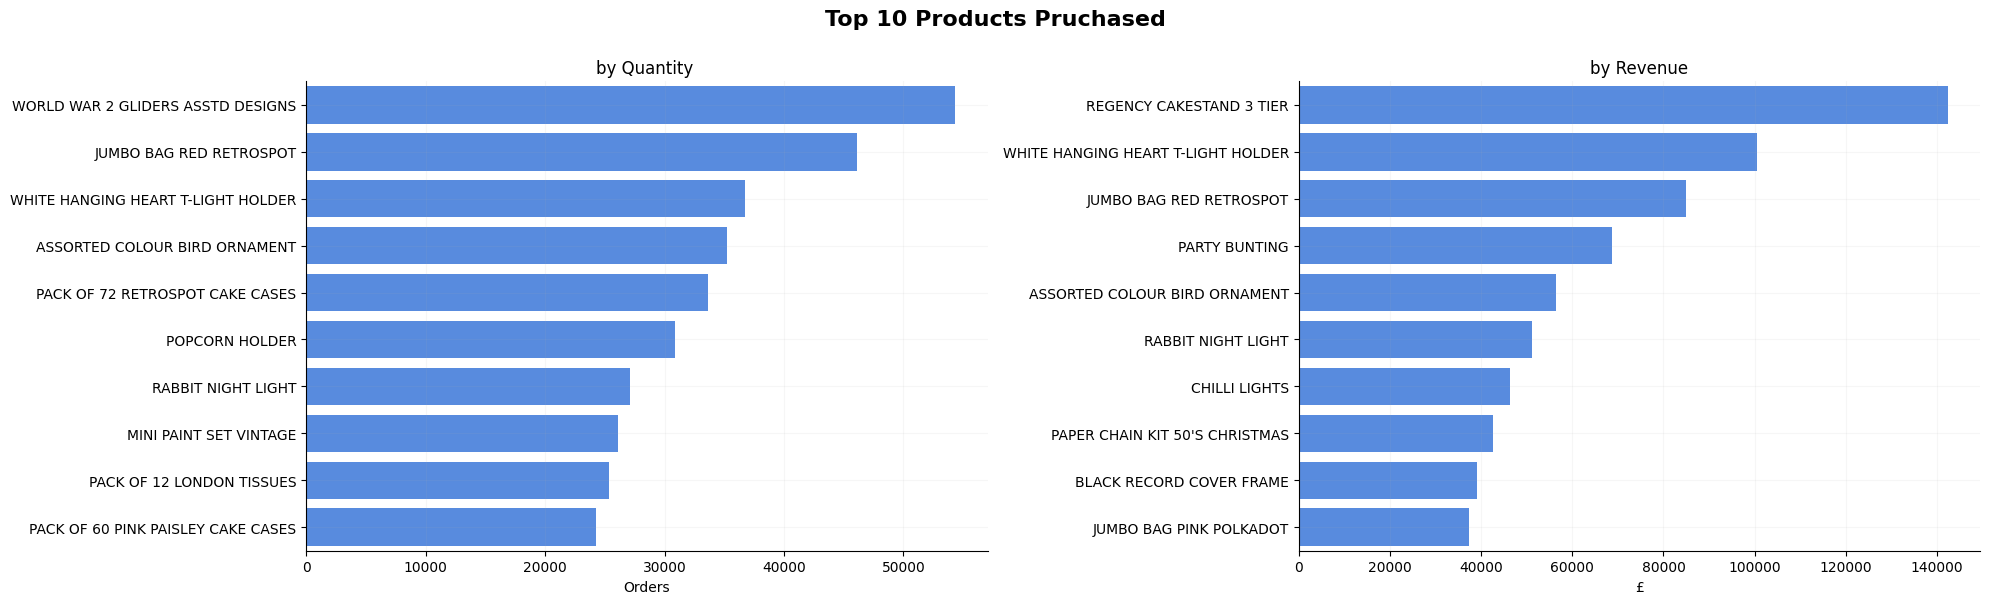

In [55]:
# creating figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))


# transaction plot
sns.barplot(
    y=top_products_qty.index, 
    x=top_products_qty.values, 
    ax=ax1, 
    color="#4285F4",
    order=top_products_qty.index
    )

ax1.set_title('by Quantity ', fontsize=12)
ax1.set_ylabel('')
ax1.set_xlabel('Orders')

# revenue plot
sns.barplot(
    y=top_products_revenue.index,
    x=top_products_revenue.values,
    ax=ax2,
    color="#4285F4",
    order=top_products_revenue.index
)
ax2.set_title('by Revenue', fontsize=12)
ax2.set_ylabel('')
ax2.set_xlabel('£')

# Format revenue axis

ax1.grid(True, alpha=0.1)
ax2.grid(True, alpha=0.1)
sns.despine(ax=ax1)
sns.despine(ax=ax2)


plt.suptitle('Top 10 Products Pruchased',fontsize=16, fontweight='bold',y=1)

plt.tight_layout()
plt.show()

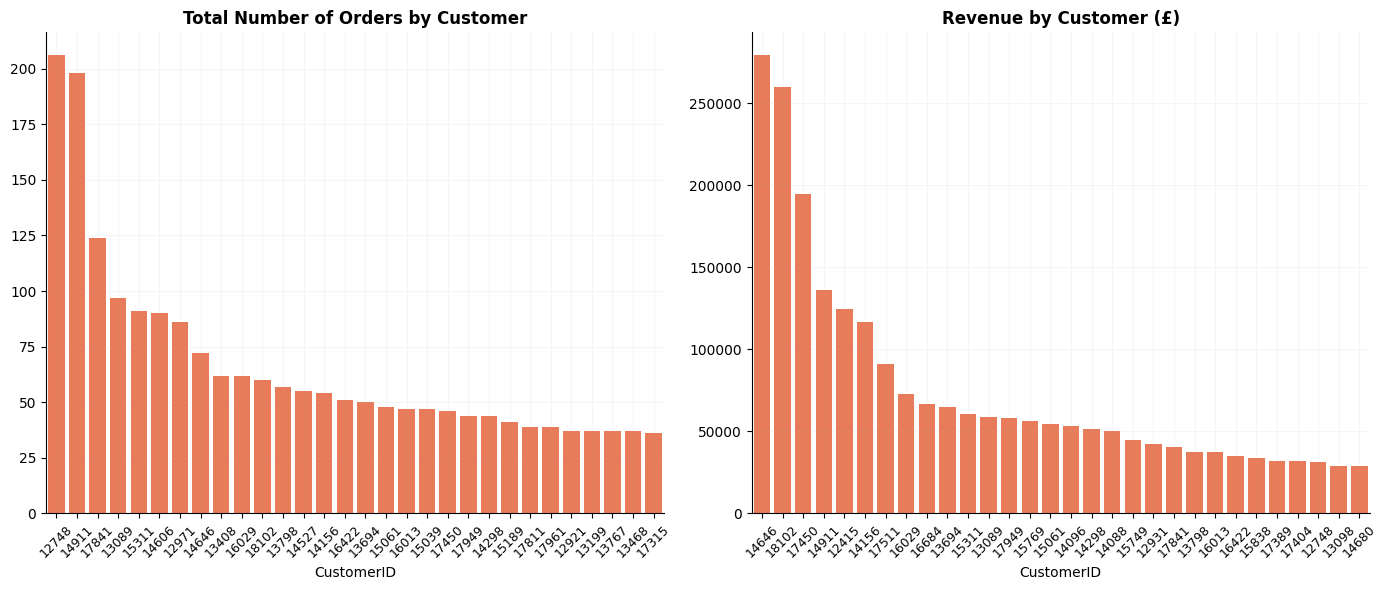

In [56]:
# creating figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Total revenue per customer
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(30)

# Total quantity per customer
customer_total_orders = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head(30)

# transaction plot
sns.barplot(
    x=customer_total_orders.index, 
    y=customer_total_orders.values, 
    ax=ax1, 
    color="#FF7043",
    order=customer_total_orders.index
    )

ax1.set_title('Total Number of Orders by Customer', fontsize=12, fontweight='bold')
ax1.set_ylabel('')
ax1.set_xlabel('CustomerID')

# revenue plot
sns.barplot(
    x=customer_revenue.index,
    y=customer_revenue.values,
    ax=ax2,
    color="#FF7043",
    order=customer_revenue.index
)
ax2.set_title('Revenue by Customer (£)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')
ax2.set_xlabel('CustomerID')

# Format revenue axis

ax1.grid(True, alpha=0.1)
ax2.grid(True, alpha=0.1)
sns.despine(ax=ax1)
sns.despine(ax=ax2)
ax1.tick_params(axis='x', labelrotation=45, labelsize=9)
ax2.tick_params(axis='x', labelrotation=45, labelsize=9)
# ax1.set_xlabel(rotation=45, fontsize=8)
#ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

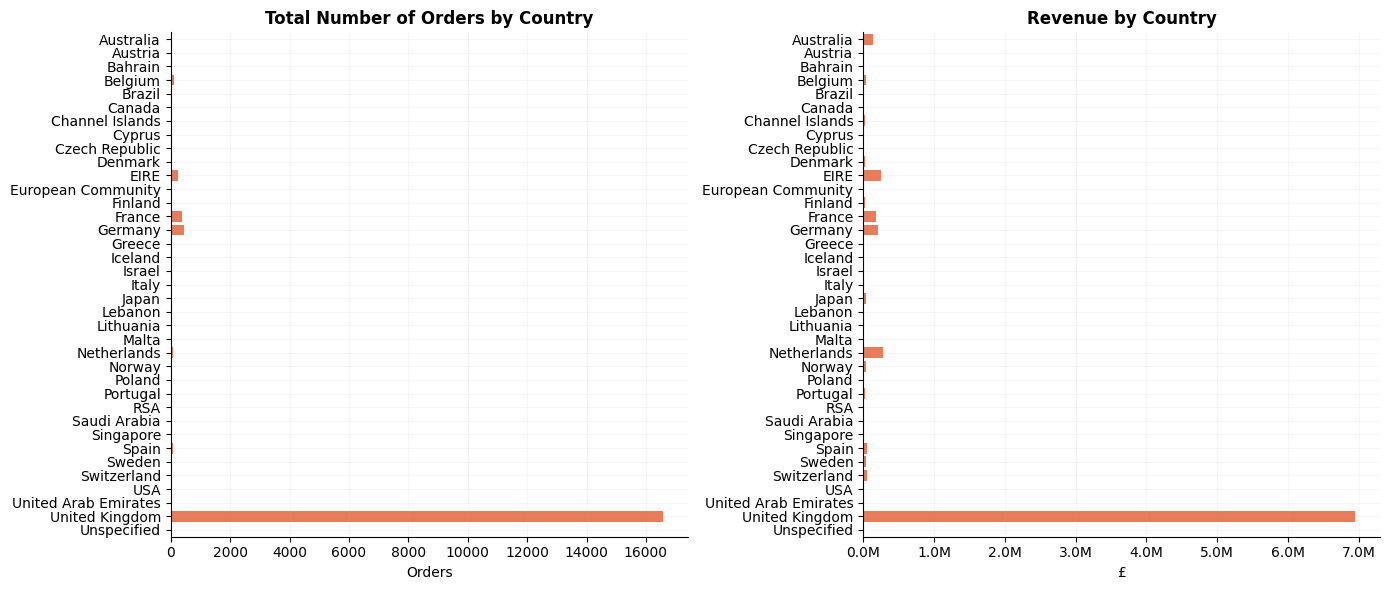

In [57]:
# creating figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# grouping by total orders and revenue by country
orders_country = df.groupby('Country')['InvoiceNo'].nunique().reset_index()
revenue_country = df.groupby('Country')['TotalPrice'].sum().reset_index()

# transaction plot
sns.barplot(
    y=orders_country['Country'], 
    x=orders_country['InvoiceNo'], 
    ax=ax1, 
    color="#FF7043"
    )

ax1.set_title('Total Number of Orders by Country', fontsize=12, fontweight='bold')
ax1.set_ylabel('')
ax1.set_xlabel('Orders')

# revenue plot
sns.barplot(
    y=revenue_country['Country'],
    x=revenue_country['TotalPrice'],
    ax=ax2,
    color="#FF7043"
)
ax2.set_title('Revenue by Country', fontsize=12, fontweight='bold')
ax2.set_ylabel('')
ax2.set_xlabel('£')

# Format revenue axis
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.grid(True, alpha=0.1)
ax2.grid(True, alpha=0.1)
sns.despine(ax=ax1)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

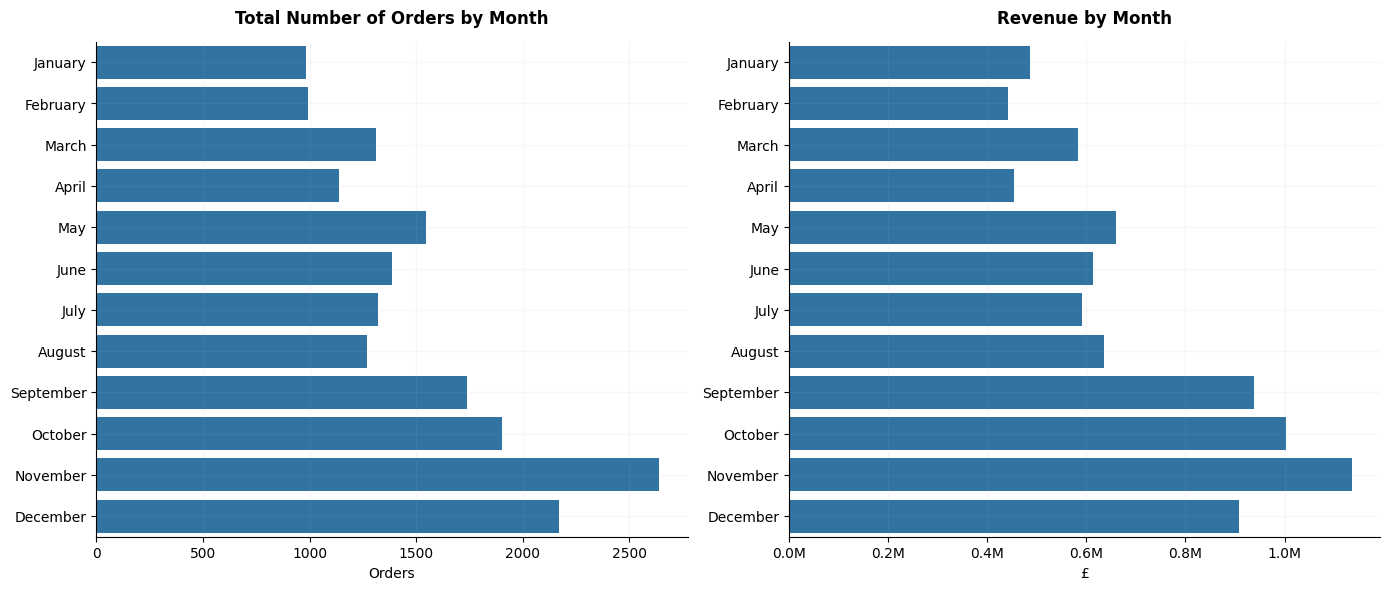

In [58]:
# month name
df['Month'] = df['InvoiceDate'].dt.month_name()

# name order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# grouping by total orders and revenue by month
monthly_orders = df.groupby('Month')['InvoiceNo'].nunique().reindex(month_order)
monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reindex(month_order)

# creating figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# transaction plot
sns.barplot(
    y=monthly_orders.index,
    x=monthly_orders.values,
    ax=ax1
)
ax1.set_title('Total Number of Orders by Month', fontsize=12, fontweight='bold', y=1.02)
ax1.set_ylabel('')
ax1.set_xlabel('Orders')

# revenue plot
sns.barplot(
    y=monthly_revenue.index,
    x=monthly_revenue.values,
    ax=ax2
)
ax2.set_title('Revenue by Month', fontsize=12, fontweight='bold', y=1.02)
ax2.set_ylabel('')
ax2.set_xlabel('£')

# format axis
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.grid(True, alpha=0.1)
ax2.grid(True, alpha=0.1)
sns.despine(ax=ax1)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

In [59]:
df = df.drop(columns=['Month'])

#### **RFM dataset**

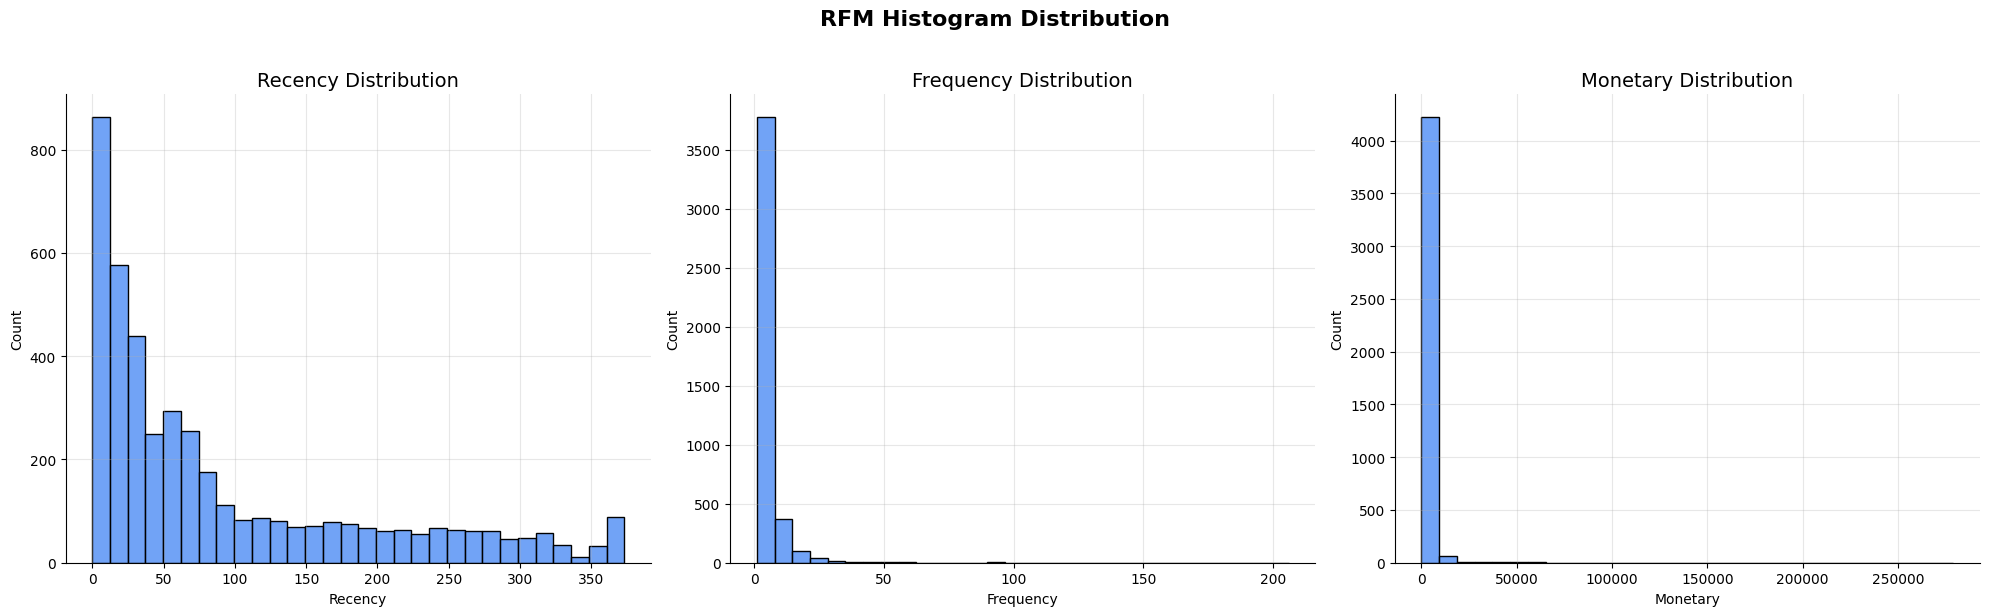

In [60]:

# creating figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# recency plot
sns.histplot(
    rfm_df['Recency'],
    bins=30, 
    ax=ax1, 
    color="#4285F4")

ax1.set_title('Recency Distribution',fontsize=14)
ax1.set_xlabel('Recency', fontsize=10)

# frequency plot
sns.histplot(
    rfm_df['Frequency'],
    bins=30, 
    ax=ax2, 
    color="#4285F4")

ax2.set_title('Frequency Distribution',fontsize=14)
ax2.set_xlabel('Frequency', fontsize=10)

# monetary plot
sns.histplot(
    rfm_df['Monetary'],
    bins=30, 
    ax=ax3, 
    color="#4285F4")

ax3.set_title('Monetary Distribution',fontsize=14)
ax3.set_xlabel('Monetary', fontsize=10)

# Format axis
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
ax3.grid(True, alpha=0.3)
sns.despine(ax=ax1)
sns.despine(ax=ax2)
sns.despine(ax=ax3)

plt.suptitle('RFM Histogram Distribution',fontsize=16, fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

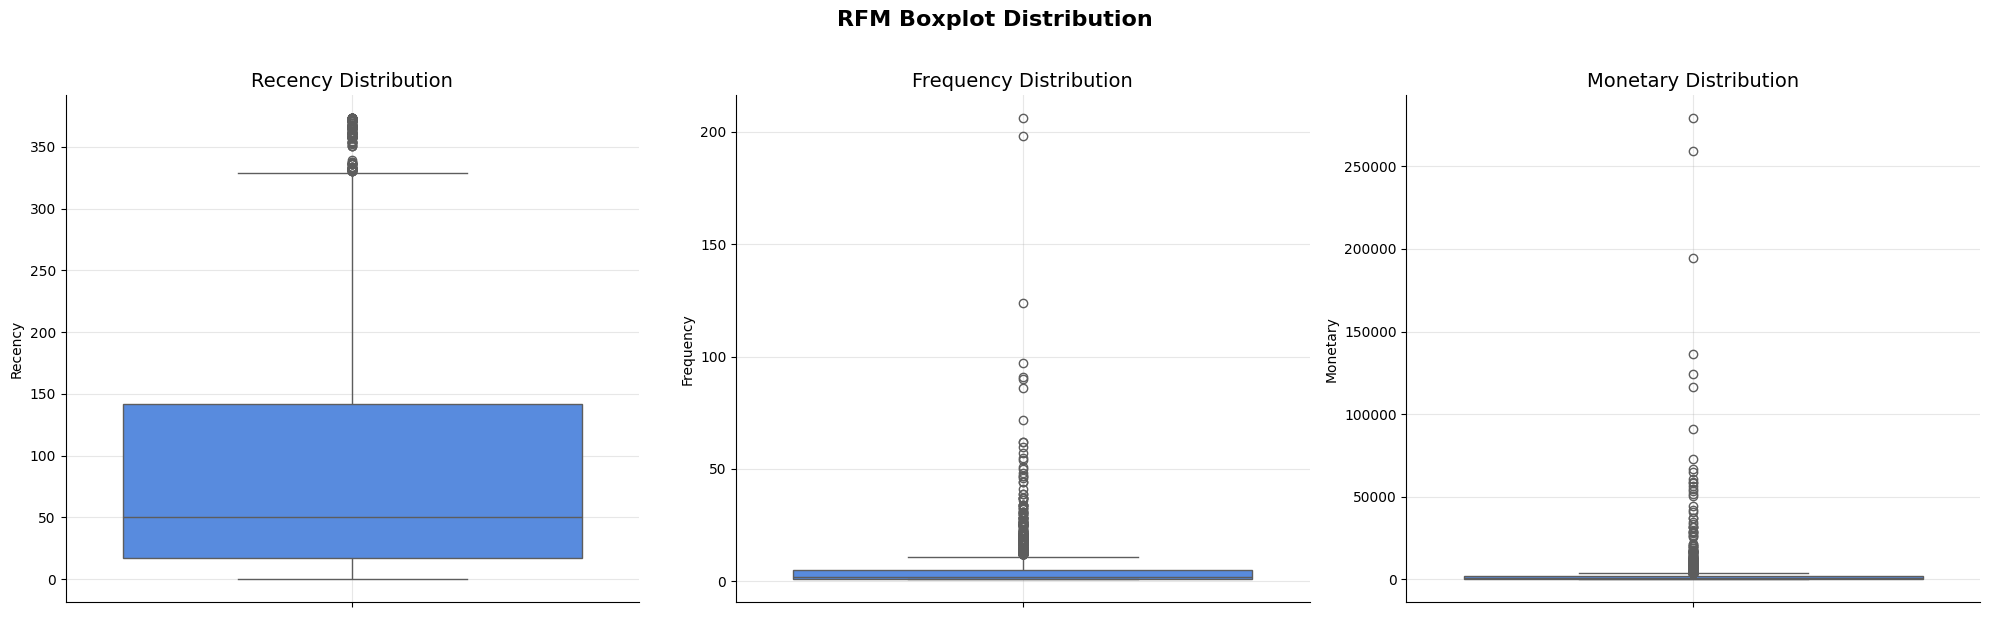

In [61]:

# creating figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))


# recency plot
sns.boxplot(
    rfm_df['Recency'],
    ax=ax1, 
    color="#4285F4")

ax1.set_title('Recency Distribution',fontsize=14)

# frequency plot
sns.boxplot(
    rfm_df['Frequency'],
    ax=ax2, 
    color="#4285F4")

ax2.set_title('Frequency Distribution',fontsize=14)

# monetary plot
sns.boxplot(
    rfm_df['Monetary'],
    ax=ax3, 
    color="#4285F4")

ax3.set_title('Monetary Distribution',fontsize=14)

# Format axis
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
ax3.grid(True, alpha=0.3)
sns.despine(ax=ax1)
sns.despine(ax=ax2)
sns.despine(ax=ax3)

plt.suptitle('RFM Boxplot Distribution',fontsize=16, fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

Evaluating the distributions, the figures show high number of outliers on Frequency and Monetary columns.       
Recency has some outliers, but outliers are good information for this kind of dataset.      
Since K-Means clustering is sensitive to outliers, extreme values will be treated carefully before clustering to minimise their influence without unnecessarily removing valid observations.

## Exporting datasets

In [62]:
df.to_csv('../datasets/01_cleaned_data.csv', index=False)

In [63]:
rfm_df.to_csv('../datasets/01_rfm_df.csv', index=False)

##